##  Utforska och fördjupa er i neurala nätverk

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

Dataset shape:
X shape: (70000, 28, 28)
y shape: (70000,)

Classes in dataset:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot

Class distribution:
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


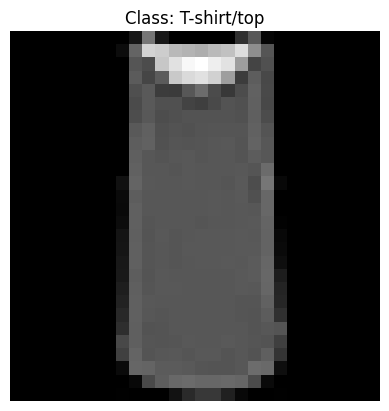

In [14]:
# --------------------------------------------
# 1. Load dataset
# --------------------------------------------

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Combine train and test data
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

# --------------------------------------------
# 2. Explore dataset
# --------------------------------------------

print("Dataset shape:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("\nClasses in dataset:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# Class distribution
class_distribution = pd.Series(y).value_counts().sort_index()

print("\nClass distribution:")
print(class_distribution)

# --------------------------------------------
# 3. Show sample image
# --------------------------------------------

plt.imshow(X[2], cmap="gray")
plt.title(f"Class: {class_names[y[2]]}")
plt.axis("off")
plt.show()



## Resultat 
- Datasetet består av 70 000 bilder från Fashion-MNIST.
- Datasetet innehåller totalt tio klasser, representerade av etiketterna 0–9. Klassfördelningen visar att varje klass innehåller exakt 7 000 bilder.
- Detta innebär att datasetet är balanserat och att det inte finns någon klassobalans som riskerar att påverka modellträningen negativt.

In [15]:
# --------------------------------------------
# 4. Train/Test split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# Validation split
# --------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    random_state=42,
    stratify=y_train
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Val shape:", X_val.shape)

# --------------------------------------------
# 5. Normalize images
# --------------------------------------------

X_train = X_train / 255.0
X_test = X_test / 255.0
X_val = X_val / 255.0

print("\nPixel range after normalization:")
print("Min:", X_train.min())
print("Max:", X_train.max())

# --------------------------------------------
# 6A. Reshape for Dense model
# --------------------------------------------

X_train_dense = X_train.reshape(-1, 784)
X_test_dense = X_test.reshape(-1, 784)
X_val_dense = X_val.reshape(-1, 784)

print("\nDense model shape:")
print("X_train_dense:", X_train_dense.shape)
print("X_test_dense:", X_test_dense.shape)
print("X_val_dense:", X_val_dense.shape)

# --------------------------------------------
# 6B. Reshape for CNN model
# --------------------------------------------

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)

print("\nCNN model shape:")
print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)
print("X_val_cnn:", X_val_cnn.shape)


Train shape: (49000, 28, 28)
Test shape: (14000, 28, 28)
Val shape: (7000, 28, 28)

Pixel range after normalization:
Min: 0.0
Max: 1.0

Dense model shape:
X_train_dense: (49000, 784)
X_test_dense: (14000, 784)
X_val_dense: (7000, 784)

CNN model shape:
X_train_cnn: (49000, 28, 28, 1)
X_test_cnn: (14000, 28, 28, 1)
X_val_cnn: (7000, 28, 28, 1)


In [16]:
## First model 

base_model = keras.Sequential([
    # Input lager
    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    # Gör om till 1D
    layers.Flatten(),

    # Dense-lager
    layers.Dense(128, activation="relu"),

    # Dropout lager
    layers.Dropout(0.5),

    # Outputlager
    layers.Dense(10, activation="softmax")
])

base_model.summary()

c:\Users\Jakob\Desktop\DeepLearningExamModellarkitektur-main\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
## Säkerställer att modellen fungerar 

base_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = base_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7521 - loss: 0.6838 - val_accuracy: 0.8290 - val_loss: 0.4578
Epoch 2/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8356 - loss: 0.4516 - val_accuracy: 0.8560 - val_loss: 0.3936
Epoch 3/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8608 - loss: 0.3828 - val_accuracy: 0.8761 - val_loss: 0.3360
Epoch 4/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8767 - loss: 0.3399 - val_accuracy: 0.8791 - val_loss: 0.3199
Epoch 5/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8872 - loss: 0.3113 - val_accuracy: 0.8843 - val_loss: 0.3156
Epoch 6/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8951 - loss: 0.2886 - val_accuracy: 0.8824 - val_loss: 0.3131
Epoch 7/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9012 - loss: 0.2682 - val_accuracy: 0.8840 - val_loss: 0.3223
Epoch 8/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9088 - loss: 0.2

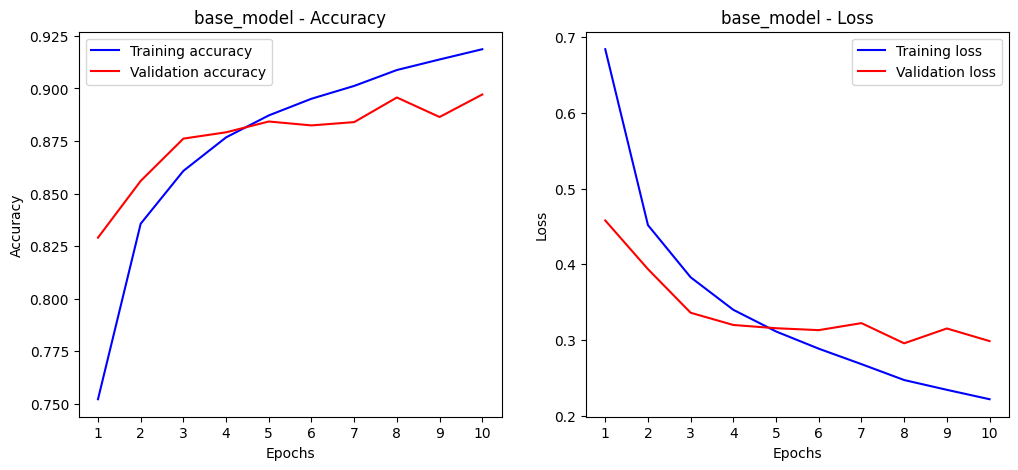

In [18]:
# Funktion för att plotta loss och accuracy. Ange history och vad du vill ha för titel i plotten =)
def plot_training_history(history, model_name="Grundmodell"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plotta Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs)
    plt.legend()

    # Plotta Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.legend()

    plt.show()

# Anropar funktionen med den tidigare historyn
plot_training_history(history, "base_model") 